In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../src/models/saved")

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_val   = pd.read_csv(PROCESSED_DIR / "X_val.csv")
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test  = pd.read_csv(PROCESSED_DIR / "y_test_evil.csv")['evil'].values

scaler     = joblib.load(MODELS_DIR / "scaler.pkl")
iso_forest = joblib.load(MODELS_DIR / "isolation_forest.pkl")

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

scaler_params = np.load(PROCESSED_DIR / "scaler_params.npy")
risk_min, risk_max = scaler_params[0], scaler_params[1]

with open(PROCESSED_DIR / "model_metadata.json") as f:
    if_meta = json.load(f)

print(f"Data loaded ✅")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

Data loaded ✅
X_train: (763144, 10) | X_val: (188967, 10) | X_test: (188967, 10)


In [2]:
# Use continuous IF risk scores as targets — not binary 0/1
raw_scores_train = iso_forest.decision_function(X_train_scaled)
raw_scores_val   = iso_forest.decision_function(X_val_scaled)

risk_train = np.clip((-raw_scores_train - risk_min) / (risk_max - risk_min), 0, 1)
risk_val   = np.clip((-raw_scores_val   - risk_min) / (risk_max - risk_min), 0, 1)

print("=== SOFT LABEL STATS ===")
print(f"Train — min:{risk_train.min():.3f}  max:{risk_train.max():.3f}  mean:{risk_train.mean():.3f}")
print(f"Val   — min:{risk_val.min():.3f}  max:{risk_val.max():.3f}  mean:{risk_val.mean():.3f}")
print(f"\nHigh risk (>0.7) in train : {(risk_train > 0.7).sum():,}")
print(f"Low risk  (<0.3) in train : {(risk_train < 0.3).sum():,}")
print("Soft labels created ✅")

=== SOFT LABEL STATS ===
Train — min:0.000  max:1.000  mean:0.224
Val   — min:0.000  max:0.974  mean:0.219

High risk (>0.7) in train : 10,165
Low risk  (<0.3) in train : 567,741
Soft labels created ✅


In [3]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)

print("Training XGBoost Regressor (distilling IF scores)...")
xgb_model.fit(
    X_train, risk_train,
    eval_set=[(X_val, risk_val)],
    verbose=50
)

print(f"\nBest iteration : {xgb_model.best_iteration}")
print("Training complete ✅")
joblib.dump(xgb_model, MODELS_DIR / "xgboost_model.pkl")
print("Model saved ✅")

Training XGBoost Regressor (distilling IF scores)...
[0]	validation_0-rmse:0.13465
[50]	validation_0-rmse:0.04715
[100]	validation_0-rmse:0.03208
[150]	validation_0-rmse:0.02116
[200]	validation_0-rmse:0.01419
[250]	validation_0-rmse:0.01107
[299]	validation_0-rmse:0.00952

Best iteration : 299
Training complete ✅
Model saved ✅


In [4]:
extreme_attack = np.array([[0, 0, 1, 1, 0, 0, 1, 1, 1, 4.5]])
extreme_normal = np.array([[1, 0, 0, 0, 1, 0.9, 0.1, 0, 0, 0.5]])

atk = float(np.clip(xgb_model.predict(extreme_attack)[0], 0, 1))
nrm = float(np.clip(xgb_model.predict(extreme_normal)[0], 0, 1))

print("=== SANITY CHECK ===")
print(f"Extreme ATTACK : {atk*100:.1f}%")
print(f"Extreme NORMAL : {nrm*100:.1f}%")
print(f"Gap            : {(atk-nrm)*100:.1f} points")

dist = np.clip(xgb_model.predict(X_test), 0, 1)
print(f"\nScore distribution on test:")
print(pd.Series(dist).describe())

=== SANITY CHECK ===
Extreme ATTACK : 89.2%
Extreme NORMAL : 33.8%
Gap            : 55.5 points

Score distribution on test:
count    188967.000000
mean          0.812221
std           0.166976
min           0.003297
25%           0.861170
50%           0.874001
75%           0.878970
max           0.977609
dtype: float64


In [6]:
xgb_proba = np.clip(xgb_model.predict(X_test), 0, 1)

pr_auc = average_precision_score(y_test, xgb_proba)
print("=== XGBoost EVALUATION ===")
print(f"PR-AUC : {pr_auc:.4f}")

precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx  = np.argmax(f1_scores[:-1])
best_thr  = thresholds[best_idx]
best_f1   = f1_scores[best_idx]

print(f"Best threshold : {best_thr:.4f}")
print(f"Best F1 score  : {best_f1:.4f}")

y_pred = (xgb_proba >= best_thr).astype(int)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Evil']))

cm = confusion_matrix(y_test, y_pred)
print("=== CONFUSION MATRIX ===")
print(f"True  Negatives : {cm[0,0]:,}")
print(f"False Positives : {cm[0,1]:,}")
print(f"False Negatives : {cm[1,0]:,}")
print(f"True  Positives : {cm[1,1]:,}")
print(f"Recall (% evil caught): {cm[1,1]/(cm[1,0]+cm[1,1])*100:.2f}%")

=== XGBoost EVALUATION ===
PR-AUC : 0.9955
Best threshold : 0.7735
Best F1 score  : 0.9904

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95     30535
        Evil       0.99      0.99      0.99    158432

    accuracy                           0.98    188967
   macro avg       0.96      0.98      0.97    188967
weighted avg       0.98      0.98      0.98    188967

=== CONFUSION MATRIX ===
True  Negatives : 29,669
False Positives : 866
False Negatives : 2,171
True  Positives : 156,261
Recall (% evil caught): 98.63%


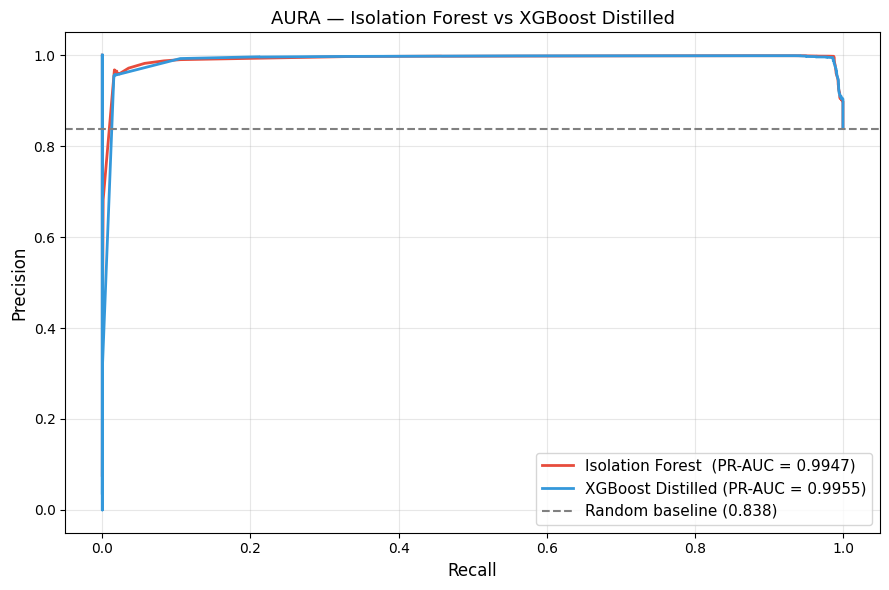

Chart saved ✅


In [7]:
if_scores = np.load(PROCESSED_DIR / "if_risk_scores.npy") / 100
if_pr_auc = average_precision_score(y_test, if_scores)

prec_if,  rec_if,  _ = precision_recall_curve(y_test, if_scores)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)

plt.figure(figsize=(9, 6))
plt.plot(rec_if,  prec_if,  color='#e74c3c', lw=2,
         label=f'Isolation Forest  (PR-AUC = {if_pr_auc:.4f})')
plt.plot(rec_xgb, prec_xgb, color='#3498db', lw=2,
         label=f'XGBoost Distilled (PR-AUC = {pr_auc:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Random baseline ({y_test.mean():.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('AURA — Isolation Forest vs XGBoost Distilled', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "pr_curve_comparison.png", dpi=150)
plt.show()
print("Chart saved ✅")

<Figure size 900x500 with 0 Axes>

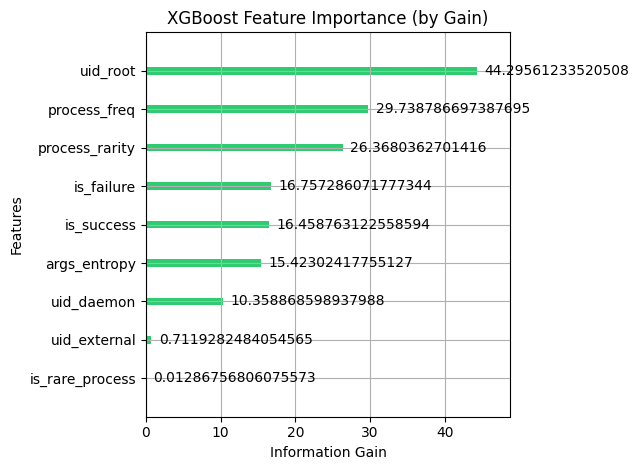

Feature importance saved ✅


In [8]:
from xgboost import plot_importance

plt.figure(figsize=(9, 5))
plot_importance(
    xgb_model,
    importance_type='gain',
    xlabel='Information Gain',
    title='XGBoost Feature Importance (by Gain)',
    max_num_features=10,
    color='#2ecc71'
)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "xgb_feature_importance.png", dpi=150)
plt.show()
print("Feature importance saved ✅")

In [9]:
np.save(PROCESSED_DIR / "xgb_proba_scores.npy", xgb_proba)

with open(PROCESSED_DIR / "xgb_metadata.json", 'w') as f:
    json.dump({
        'model': 'XGBRegressor_Distilled',
        'training_method': 'if_score_distillation',
        'n_estimators_used': int(xgb_model.best_iteration),
        'pr_auc': round(float(pr_auc), 4),
        'best_threshold': round(float(best_thr), 4),
        'best_f1': round(float(best_f1), 4),
        'gpu_used': True
    }, f, indent=2)

print("All outputs saved ✅")
print(json.dumps(json.load(open(PROCESSED_DIR / "xgb_metadata.json")), indent=2))

All outputs saved ✅
{
  "model": "XGBRegressor_Distilled",
  "training_method": "if_score_distillation",
  "n_estimators_used": 299,
  "pr_auc": 0.9955,
  "best_threshold": 0.7735,
  "best_f1": 0.9904,
  "gpu_used": true
}
